In [10]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=0)

# Dígitos manuscritos: $ k $ vizinhos mais próximos

Neste caderno vamos aplicar as técnicas do NumPy ao seguinte problema
concreto, que é difícil de resolver com uma lista de regras:


__Problema:__ Dada uma pequena imagem em tons de cinza de um dígito manuscrito,
decidir qual dos números $ 0, 1, \dots, 9 $ ele é.

Você reconhece dígitos sem esforço, mas tente escrever a regra que está usando.
O que exatamente faz de um $ 3 $ um $ 3 $? Qualquer regra que você proponha será
quebrada pela caligrafia de alguém. Esta é a situação em que vale a pena
recorrer ao aprendizado de máquina: temos exemplos de sobra e nenhuma regra
utilizável, então deixamos que os exemplos forneçam a regra.

O método deste caderno, os $ k $ __vizinhos mais próximos__, não aprende
absolutamente nada. Ele memoriza todos os exemplos e responde a novas perguntas
consultando os mais parecidos. É um método __supervisionado__: aprende a partir
de exemplos cujas respostas já conhecemos. No caderno seguinte, sobre
agrupamento por $ k $-médias, as mesmas imagens chegam com todos os rótulos
retirados.

Em ambos os cadernos, utilizaremos como base uma única identidade a respeito de
$ \Vert \boldsymbol{x} - \boldsymbol{y}\Vert^2 $ vinda da Álgebra Linear. 

📝 Este caderno acumula estado: células posteriores usam nomes definidos em
exercícios anteriores, por isto você deve executar as células em ordem.

## $ \S 1 $ Os dados

### $ 1.1 $ Dígitos manuscritos

Nosso conjunto de dados guarda $ 1797 $ imagens de dígitos manuscritos,
coletadas de $ 43 $ pessoas diferentes. Cada imagem tem $ 8 \times 8 $ pixels, e
cada pixel é um inteiro de $ 0 $ (branco) a $ 16 $ (preto). Ele vem junto com o
scikit-learn, de modo que nada precisa ser baixado.

In [11]:
from sklearn.datasets import load_digits

digitos = load_digits()

print(f"Imagens: {digitos.images.shape}")
print(f"Planas:  {digitos.data.shape}")
print(f"Rótulos: {digitos.target.shape}")
print(f"Os valores dos pixels vão de {digitos.images.min()} a {digitos.images.max()}")

Imagens: (1797, 8, 8)
Planas:  (1797, 64)
Rótulos: (1797,)
Os valores dos pixels vão de 0.0 a 16.0


Note a forma $ (1797, 8, 8) $ de `digitos.images`: trata-se de um array $ 3D $,
uma pilha de $ 1797 $ matrizes de forma $ 8 \times 8 $, exatamente como descrito
no primeiro caderno. Vejamos uma delas como tabela de números e depois como
figura.

In [12]:
print(digitos.images[0].astype(int))
print(f"\nEsta imagem está rotulada como: {digitos.target[0]}")

[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]

Esta imagem está rotulada como: 0


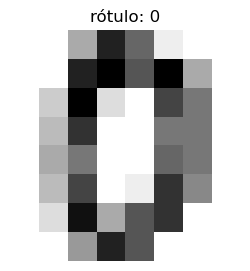

In [13]:
fig, ax = plt.subplots(figsize=(3, 3))

ax.imshow(digitos.images[0], cmap="gray_r")
ax.set_title(f"rótulo: {digitos.target[0]}")
ax.axis("off")

plt.show()

Aperte os olhos diante da tabela de números acima e você já consegue ver o
dígito: os valores grandes desenham o seu contorno. A imagem e a matriz são o
mesmo objeto.

__Exercício:__ Exiba um exemplo de cada um dos dez dígitos em uma única figura.
Complete o laço abaixo. _Dica:_ `np.where(digitos.target == c)[0]` fornece os
índices de todas as imagens rotuladas como `c`; tome o primeiro. O comando
`axes.flat` permite percorrer uma grade de subplots como se fosse uma lista.

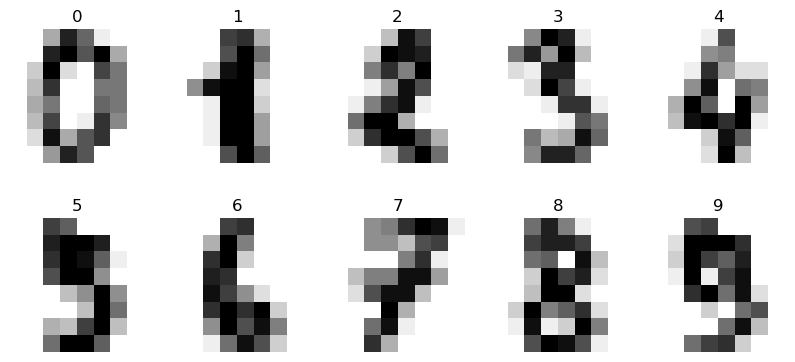

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))

for c, ax in enumerate(axes.flat):
    # indice = ...
    ax.imshow(digitos.images[indice], cmap="gray_r")
    ax.set_title(str(c))
    ax.axis("off")

plt.show()

__Exercício:__ Os dez dígitos estão igualmente representados no conjunto de
dados? Conte quantas vezes cada rótulo ocorre. _Dica:_ `np.bincount` conta as
ocorrências de cada inteiro não negativo de um array. Alternativamente, use uma
máscara booleana e `np.sum` dentro de um laço.

In [ ]:
# contagens = ...

print(contagens)
print(f"Dígito menos comum: {contagens.argmin()} ({contagens.min()} imagens)")

[178 182 177 183 181 182 181 179 174 180]
Dígito menos comum: 8 (174 imagens)


### $ 1.2 $ Uma imagem é um ponto de $ \mathbb{R}^{64} $

Eis o movimento conceitual sobre o qual repousa tudo neste caderno. Tome a
matriz $ 8 \times 8 $ de valores dos pixels e leia-a linha a linha, formando uma
única lista de $ 64 $ números. Esta lista é um vetor de $ \mathbb{R}^{64} $.

$$
\boxed{\ \text{uma imagem } 8 \times 8 \ \longleftrightarrow \ \text{um ponto } \boldsymbol{x} \in \mathbb{R}^{64}\ }
$$

<p align="center">
  <img src="05_imagem_como_vetor.png" width="820">
  <br>
  <em>Figura 1: Achatando uma imagem. As oito linhas são postas uma após a outra, em ordem.</em>
</p>

O conjunto de dados já fornece esta forma achatada, em `digitos.data`, cuja
forma é $ (1797, 64) $: _uma linha por imagem, uma coluna por pixel_. Esta é a
mesma convenção que sempre usamos, com as amostras nas linhas.

Não conseguimos visualizar $ \mathbb{R}^{64} $, mas toda ferramenta que
construímos para vetores continua funcionando lá sem modificação. Em particular,
podemos medir a distância entre duas imagens:
$$
    \Vert \boldsymbol{x} - \boldsymbol{y} \Vert = \sqrt{\sum_{j=1}^{64}(x_j - y_j)^2}\,,
$$
que soma, pixel a pixel, o quanto as duas imagens estão sombreadas de forma
diferente. Distância pequena deveria significar que as duas imagens se parecem.
Verifiquemos que é o caso.

In [ ]:
zeros = np.where(digitos.target == 0)[0]    # índices das imagens rotuladas como 0
seis = np.where(digitos.target == 6)[0]

a = digitos.data[zeros[0]]

print(f"de 0 para outro 0: {np.linalg.norm(a - digitos.data[zeros[1]]):.1f}")
print(f"de 0 para um 6:    {np.linalg.norm(a - digitos.data[seis[0]]):.1f}")

de 0 para outro 0: 23.7
de 0 para um 6:    48.6


### $ 1.3 $ Preparando os dados

Dois pequenos preparativos antes de começar.

Primeiro dividimos os valores dos pixels por $ 16 $, para que fiquem em
$ [0, 1] $ em vez de $ [0, 16] $. Isto não muda nada quanto à geometria, já que
multiplica todas as distâncias pelo mesmo fator, e portanto não pode alterar
qual ponto está mais próximo de qual. Serve apenas para manter os números em uma
faixa conveniente.

Segundo, separamos os dados em um __conjunto de treino__ e um __conjunto de
teste__. Os métodos abaixo só verão o conjunto de treino. O conjunto de teste
fica guardado a sete chaves e é usado uma única vez, ao final, para medir o
desempenho sobre imagens que não tiveram parte alguma na construção do modelo.
Relatar acurácia sobre dados que o modelo já viu é a maneira mais comum de
enganar a si mesmo neste assunto.

In [18]:
from sklearn.model_selection import train_test_split

X = digitos.data / 16.0
y = digitos.target

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Conjunto de treino: {X_treino.shape}")
print(f"Conjunto de teste:  {X_teste.shape}")

Conjunto de treino: (1437, 64)
Conjunto de teste:  (360, 64)


📝 O argumento `stratify=y` pede que os dez dígitos apareçam nos conjuntos de
treino e de teste nas mesmas proporções em que aparecem no conjunto completo.
Sem ele, uma divisão aleatória poderia por acaso nos deixar com pouquíssimos
exemplos de algum dígito.

## $ \S 2 $ $ k $ vizinhos mais próximos

### $ 2.1 $ A ideia inteira, em uma frase

_Para classificar uma imagem nova, encontre as imagens de treino mais próximas
dela e deixe que votem._

É este o método por inteiro. Não há modelo a ajustar nem equação a resolver. O
algoritmo é:

1. Calcular a distância do ponto novo a cada ponto de treino.
2. Guardar as $ k $ menores.
3. Devolver o rótulo que ocorre com mais frequência entre estes $ k $.

<p align="center">
  <img src="05_votacao_knn.png" width="780">
  <br>
  <em>Figura 2: A votação, no plano. Os dois painéis usam os mesmos dados e o mesmo ponto novo, e discordam.</em>
</p>

A figura já mostra que $ k $ não é um detalhe: o ponto novo está em uma região
rarefeita, onde os três vizinhos mais próximos por acaso pertencem a uma classe
enquanto a vizinhança mais ampla pertence à outra. Voltamos à escolha de $ k $
em $ \S 2.5 $.

Tudo o que há de interessante está no passo $ 1 $, que é onde mora a álgebra
linear.

__Exercício:__ Classifique uma única imagem de teste na mão, com $ k = 1 $.

(a) Tome `X_teste[0]` e calcule sua distância a cada uma das $ 1437 $ imagens de
    treino, obtendo um array $ 1D $ de $ 1437 $ distâncias. O broadcasting faz
    isto em uma linha: `X_treino - X_teste[0]` subtrai o vetor de teste de cada
    linha de `X_treino`. Em seguida aplique `np.linalg.norm` com `axis=1`, para
    que a norma seja tomada ao longo de cada linha.

(b) Encontre o índice da menor distância com `np.argmin`.

(c) Compare o rótulo desta imagem de treino mais próxima com o rótulo verdadeiro
    `y_teste[0]` executando o código discriminado abaixo. O método acertou?

In [ ]:
# (a)
# diferencas = ...
# distancias = ...
print(distancias.shape)

# (b)
# mais_proximo = ...

# (c)
print(f"Rótulo verdadeiro: {y_teste[0]}, vizinho mais próximo: {y_treino[mais_proximo]}")

(1437,)
Rótulo verdadeiro: 5, vizinho mais próximo: 5


Vamos desenhar lado a lado a imagem de teste e a imagem de treino mais
próxima. Para exibir um vetor plano de $ 64 $ números como imagem,
precisamos remodelá-la de volta para $ (8, 8) $.

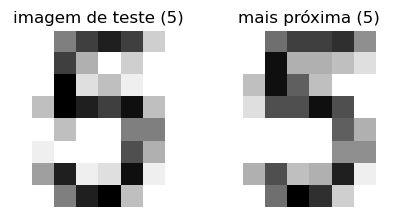

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(5, 3))

axes[0].imshow(X_teste[0].reshape(8, 8), cmap="gray_r")
axes[0].set_title(f"imagem de teste ({y_teste[0]})")
axes[1].imshow(X_treino[mais_proximo].reshape(8, 8), cmap="gray_r")
axes[1].set_title(f"mais próxima ({y_treino[mais_proximo]})")
for ax in axes:
    ax.axis("off")

plt.show()

### $ 2.2 $ Todas as distâncias de uma vez

Fazer isto uma imagem de teste por vez exigiria um laço de Python sobre as
$ 360 $ imagens de teste, e a esta altura você já sabe como isto termina.
Queremos a __matriz de distâncias__ $ D $ inteira, de forma $ (360, 1437) $,
cuja entrada $ D_{ij} $ é a distância da imagem de teste $ i $ à imagem de
treino $ j $.

O broadcasting pode produzi-la diretamente. Inserir um novo eixo em cada operando
alinha os dois arrays ao longo de dimensões distintas:

```
    X_teste[:, None, :]     (360,    1, 64)
    X_treino[None, :, :]    (  1, 1437, 64)
    -----------------------------------------  broadcast
    diferença               (360, 1437, 64)
    norma ao longo do eixo 2 (360, 1437)
```

__Exercício:__ Construa a matriz de distâncias deste modo e confira a sua forma.

In [ ]:
# D_lenta = np.linalg.norm(...)

print(D_lenta.shape)

(360, 1437)


⚠️ Esta linha funciona, mas veja o que ela custa. O array $ 3D $ intermediário
tem $ 360 \times 1437 \times 64 $ entradas de $ 8 $ bytes cada, o que dá cerca
de $ 265 $ megabytes de memória, tudo para produzir um resultado final de
$ 360 \times 1437 $ números que ocupam $ 4 $ megabytes. Erguemos uma montanha
para entregar um montinho de terra. Com um conjunto de treino dez vezes maior,
esta linha esgotaria a memória da maioria dos laptops.

### $ 2.3 $ Uma matriz de distâncias melhor

A linha acima é vetorizada, e ainda assim, é muito custosa. Eliminar o laço
de Python foi uma transformação mecânica do código, mas o que precisamos fazer é
reescrever o _problema_. A álgebra linear oferece uma saída. Expanda a distância
ao quadrado usando a bilinearidade do produto escalar, exatamente como você
expandiria $ (a-b)^2 $:

$$
\boxed{\ \Vert \boldsymbol{x} - \boldsymbol{y} \Vert^2
= (\boldsymbol{x} - \boldsymbol{y})\cdot(\boldsymbol{x} - \boldsymbol{y})
= \Vert \boldsymbol{x} \Vert^2 - 2\,\boldsymbol{x} \cdot \boldsymbol{y} + \Vert \boldsymbol{y} \Vert^2\ }
$$

Agora leia isto uma entrada por vez. O termo do meio, para todos os pares
$ (i, j) $ de uma só vez, é a matriz de todos os produtos escalares entre as
linhas de teste e as de treino, que é precisamente o produto matricial

$$
    G = X_{\text{teste}}\, X_{\text{treino}}^T \qquad \text{de forma } (360, 1437)\,.
$$

Os outros dois termos dependem de um único índice cada, de modo que são uma
coluna e uma linha que se espalham por $ G $. Nenhum array $ 3D $ chega a ser
construído, e a parte cara se reduz a uma única multiplicação de matrizes, que o
NumPy entrega a uma rotina fortemente otimizada.

<p align="center">
  <img src="05_dois_caminhos.png" width="820">
  <br>
  <em>Figura 3: Dois caminhos até a mesma matriz 360, 1437).</em>
</p>

__Exercício:__ Escreva a função `distancias_quadradas`. Vamos usá-la no resto do
caderno.

(a) Calcule as normas ao quadrado das linhas de cada argumento.
    _Dica:_ `np.sum(A ** 2, axis=1)`.

(b) Monte a matriz das distâncias ao quadrado como
    `quad_a[:, None] - 2 * (A @ B.T) + quad_b[None, :]`. Certifique-se de
    entender por que os `None` estão onde estão.

(c) Trunque o resultado com `np.maximum(..., 0)`. Em aritmética exata estes
    números são todos não negativos, mas o arredondamento pode produzir um valor
    negativo minúsculo, e mais adiante vamos querer extrair uma raiz quadrada.

In [ ]:
def distancias_quadradas(A, B):
    """
    Calcula todas as distâncias euclidianas ao quadrado entre as linhas de A e de B.

    Parâmetros
    ----------
    A : ndarray de forma (n, p)
    B : ndarray de forma (m, p)

    Retorna
    -------
    ndarray de forma (n, m)
        A entrada (i, j) é a distância ao quadrado da linha i de A à linha j de B.
    """
    # quad_a = ...
    # quad_b = ...
    return np.maximum(quad_a[:, None] - 2 * (A @ B.T) + quad_b[None, :], 0)


D = np.sqrt(distancias_quadradas(X_teste, X_treino))

print(D.shape)
print(np.allclose(D, D_lenta))

(360, 1437)
True


__Exercício:__ Cronometre as duas versões com `%timeit` e compare. O ganho deve
ficar entre uma e duas ordens de grandeza, além da memória economizada.

In [24]:
%timeit np.linalg.norm(X_teste[:, None, :] - X_treino[None, :, :], axis=2)
%timeit np.sqrt(distancias_quadradas(X_teste, X_treino))

85.5 ms ± 419 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.48 ms ± 16.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


📝 As duas versões são vetorizadas no sentido do caderno anterior: nenhuma delas
contém um laço de Python. A diferença entre elas não está no código, e sim na
álgebra, e nenhuma quantidade de ajustes na primeira expressão teria encontrado
a segunda. Vale guardar esta distinção. Vetorizar o código é mecânico; vetorizar
o problema significa achar uma formulação diferente, e é aí que se escondem os
fatores grandes.

Agora que calcular muitas distâncias saiu barato, vejamos se a distância de fato
acompanha a semelhança visual em todo o conjunto de dados. Vamos construir o
o array $ 10 \times 10 $ cuja entrada $ (a, b) $ é a distância média entre uma imagem
rotulada $ a $ e uma imagem rotulada $ b $, e exibi-la.

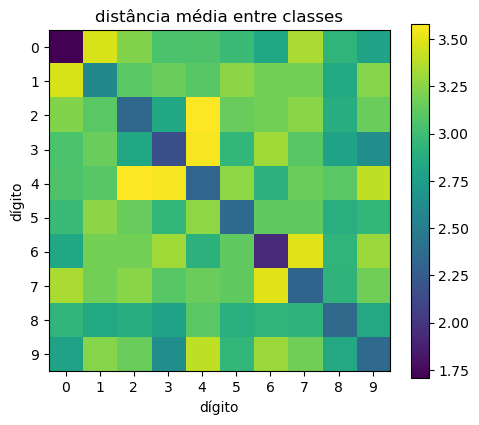

A diagonal é a menor de sua linha: True
Par de dígitos distintos mais próximo: 9 e 3


In [25]:
D_completa = np.sqrt(distancias_quadradas(X, X))
distancia_media = np.array([[D_completa[y == a][:, y == b].mean()
                             for b in range(10)] for a in range(10)])

fig, ax = plt.subplots(figsize=(5.5, 4.6))

imagem = ax.imshow(distancia_media, cmap="viridis")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel("dígito")
ax.set_ylabel("dígito")
ax.set_title("distância média entre classes")
fig.colorbar(imagem, ax=ax)

plt.show()

fora_da_diagonal = distancia_media + np.diag(np.full(10, np.inf))
a, b = np.unravel_index(fora_da_diagonal.argmin(), fora_da_diagonal.shape)
print(f"A diagonal é a menor de sua linha: {np.all(distancia_media.argmin(axis=1) == np.arange(10))}")
print(f"Par de dígitos distintos mais próximo: {a} e {b}")

Todo dígito está mais próximo de si mesmo do que de qualquer outra coisa, o que
é a razão inteira de a próxima seção funcionar. As margens não são grandes,
porém, e o par de dígitos distintos mais próximo é um par que você esperaria.

### $ 2.4 $ A votação

Com $ D $ em mãos, a linha $ i $ contém as distâncias da imagem de teste $ i $ a
todas as imagens de treino. Precisamos das $ k $ menores entradas de cada linha
e, depois, do rótulo mais comum entre elas.

`np.argsort(D, axis=1)` ordena cada linha e devolve os _índices_ em ordem
crescente de distância, de modo que as primeiras $ k $ colunas do resultado são
os $ k $ vizinhos mais próximos de cada imagem de teste. Indexar `y_treino` com
este array de índices dá um array de mesma forma contendo os rótulos deles.

__Exercício:__ Escreva o classificador.

(a) Calcule `indices_vizinhos = np.argsort(D, axis=1)[:, :k]` para `k = 3` e
    verifique que a forma é $ (360, 3) $.

(b) Obtenha `rotulos_vizinhos = y_treino[indices_vizinhos]`, de mesma forma, e
    imprima as suas cinco primeiras linhas. Os três vizinhos costumam concordar?

(c) Faça o voto majoritário em cada linha. `np.bincount(linha, minlength=10)`
    conta quantas vezes cada rótulo aparece, e `argmax` escolhe o vencedor. Uma
    compreensão de lista sobre as linhas é aceitável aqui, já que o trabalho caro
    está feito.

(d) Calcule a acurácia, a fração de imagens de teste classificadas corretamente.

In [ ]:
k = 3

# (a)
# indices_vizinhos = ...
print(indices_vizinhos.shape)

# (b)
# rotulos_vizinhos = ...
print(rotulos_vizinhos[:5])

# (c)
previsoes = np.array([np.bincount(linha, minlength=10).argmax()
                      for linha in rotulos_vizinhos])

# (d)
# acuracia = média do array booleano previsoes == y_teste
print(f"Acurácia com k = {k}: {acuracia:.4f}")

(360, 3)
[[5 5 5]
 [2 2 2]
 [8 8 8]
 [1 1 1]
 [7 7 7]]
Acurácia com k = 3: 0.9861


📝 Duas observações sobre eficiência. Primeira: ordenar uma linha inteira é
desperdício quando só queremos as suas $ k $ menores entradas;
`np.argpartition(D, k, axis=1)[:, :k]` faz o mesmo serviço sem ordenar por
completo, o que compensa assim que o conjunto de treino cresce. Segunda: empates
são possíveis quando $ k $ é par, e `argmax` os desfaz escolhendo o menor
rótulo. Esta é uma das razões pelas quais $ k $ costuma ser tomado ímpar.

### $ 2.5 $ Escolhendo $ k $

Escolhemos $ k = 3 $ sem justificativa alguma. O valor de $ k $ controla o
quanto o método suaviza: com $ k = 1 $ uma única imagem de treino mal rotulada
ou atípica pode ditar a resposta, ao passo que um $ k $ muito grande faz média
sobre vizinhos que nem são de fato parecidos. No limite $ k = n $ toda previsão
é simplesmente o dígito mais comum do conjunto de treino.

Agora vamos calcular a acurácia de teste para $ k = 1, 2, \dots, 15 $ e
representá-la graficamente contra $ k $. 

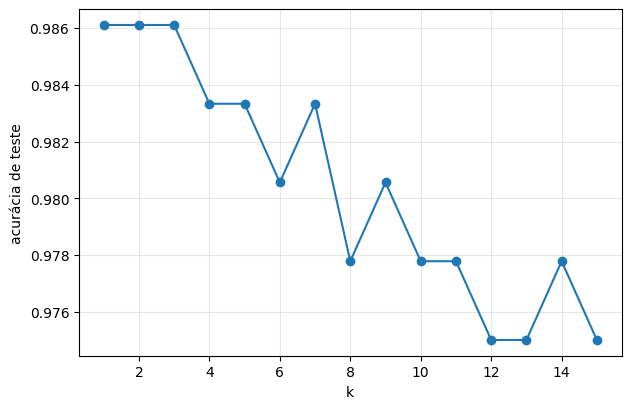

In [17]:
def knn_prever(D, y_treino, k):
    """
    Classifica amostras de teste por voto majoritário entre os k vizinhos mais próximos.

    Parâmetros
    ----------
    D : ndarray de forma (n_teste, n_treino)
        Matriz das distâncias de cada amostra de teste a cada amostra de treino.
    y_treino : ndarray de forma (n_treino,)
        Rótulos das amostras de treino.
    k : int
        Número de vizinhos a consultar.

    Retorna
    -------
    ndarray de forma (n_teste,)
        O rótulo previsto de cada amostra de teste.
    """
    rotulos_vizinhos = y_treino[np.argsort(D, axis=1)[:, :k]]
    return np.array([np.bincount(linha, minlength=10).argmax()
                     for linha in rotulos_vizinhos])


acuracias = [np.mean(knn_prever(D, y_treino, k) == y_teste) for k in range(1, 16)]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(range(1, 16), acuracias, "o-")
ax.set_xlabel("k")
ax.set_ylabel("acurácia de teste")
ax.grid(alpha=0.3)

plt.show()

Você deve encontrar acurácias em torno de $ 0.98 $ para todos os valores, com os
melhores resultados em $ k $ pequeno e um declínio lento em seguida. Acertar
cerca de $ 98\% $ dos dígitos manuscritos, com um método cuja descrição inteira
cabe em uma frase, é um resultado surpreendente.

### $ 2.6 $ Olhando para os erros

Os poucos erros são mais informativos do que os muitos acertos.

__Exercício:__ Para $ k = 3 $, encontre os índices das imagens de teste mal
classificadas com `np.where(previsoes != y_teste)[0]` e exiba-as com os rótulos
verdadeiro e previsto no título. São dígitos que uma pessoa também poderia ler
errado?

5 erros em 360


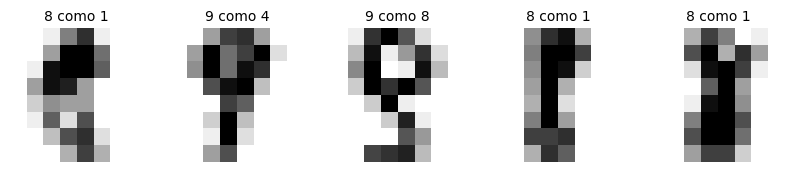

In [28]:
erros = np.where(previsoes != y_teste)[0]
print(f"{len(erros)} erros em {len(y_teste)}")

fig, axes = plt.subplots(1, len(erros), figsize=(2 * len(erros), 2.4))

for ax, indice in zip(axes.flat, erros):
    ax.imshow(X_teste[indice].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"{y_teste[indice]} como {previsoes[indice]}", fontsize=10)
    ax.axis("off")

plt.show()

### $ 2.7 $ Comparação com o scikit-learn

Como de costume, a versão da biblioteca tem uma linha e, também como de costume,
deve concordar com a nossa.

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3).fit(X_treino, y_treino)

print(f"Acurácia do scikit-learn: {knn.score(X_teste, y_teste):.4f}")

Acurácia do scikit-learn: 0.9861


Vamos verificar que `knn.predict(X_teste)` concorda com as nossas `previsoes` em
todas as imagens de teste.

In [20]:
print(np.mean(knn.predict(X_teste) == previsoes))

1.0


⚡ Antes de seguir adiante, repare na economia estranha deste método. O seu
__treinamento__ consiste em guardar os dados, e não leva tempo nenhum. Todo o
trabalho acontece no momento da __previsão__, e cada previsão exige tocar em
todas as $ 1437 $ imagens de treino. O modelo _é_ o conjunto de dados, de forma
que ele nunca pode ser menor do que o conjunto de dados. Com um milhão de
imagens de treino, o custo de memória se torna sério e cada previsão fica lenta.

Antes de trocar de pergunta, porém, vale extrair do mesmo cálculo uma saída
bem mais rica do que um único dígito.

## $ \S 3 $ De votos a probabilidades

Até aqui o classificador devolve um dígito e mais nada. Mas a votação carrega
bem mais informação do que o seu vencedor: a maneira como os $ k $ vizinhos se
repartem entre os dez dígitos é, ela própria, uma distribuição. Chamando de
$ n_c $ o número de vizinhos rotulados $ c $, definimos

$$
\boxed{\ \hat{p}(c \mid \boldsymbol{x}) = \frac{n_c}{k}\ }
$$

que é não negativa e soma $ 1 $ sobre os dez dígitos. A previsão de $ \S 2.4 $ é
apenas o $ \arg\max $ desta distribuição, de modo que não estamos trocando de
método, e sim olhando para uma saída mais fina do mesmo método.

### $ 3.1 $ A votação como uma distribuição

Vale desconfiar da palavra "probabilidade" aqui. Nada no algoritmo garante que
estes números correspondam a frequências reais de acerto. Se eles correspondem
ou não é uma pergunta empírica, e nesta seção nós a respondemos.

__Exercício:__ Escreva `knn_probabilidades`, que devolve um array de forma
$ (n_{\text{teste}}, 10) $. Verifique que cada linha soma $ 1 $ e que o
$ \arg\max $ de cada linha reproduz as `previsoes` de $ \S 2.4 $.

In [21]:
def knn_probabilidades(D, y_treino, k, n_classes=10):
    """
    Estima a probabilidade de cada classe pela fração de votos entre os k vizinhos.

    Parâmetros
    ----------
    D : ndarray de forma (n_teste, n_treino)
        Matriz das distâncias de cada amostra de teste a cada amostra de treino.
    y_treino : ndarray de forma (n_treino,)
        Rótulos das amostras de treino.
    k : int
        Número de vizinhos a consultar.
    n_classes : int, opcional
        Número de classes distintas.

    Retorna
    -------
    ndarray de forma (n_teste, n_classes)
        A entrada (i, c) é a fração dos k vizinhos da amostra i rotulados c.
    """
    rotulos_vizinhos = y_treino[np.argsort(D, axis=1)[:, :k]]
    contagens = np.array([np.bincount(linha, minlength=n_classes)
                          for linha in rotulos_vizinhos])
    return contagens / k


P = knn_probabilidades(D, y_treino, 3)

print(P.shape)
print(f"Toda linha soma 1: {np.allclose(P.sum(axis=1), 1)}")
print(f"O argmax reproduz as previsões: {np.array_equal(P.argmax(axis=1), previsoes)}")
print(f"\nPrimeira imagem de teste (verdadeiro {y_teste[0]}):")
print(np.round(P[0], 3))

(360, 10)
Toda linha soma 1: True
O argmax reproduz as previsões: True

Primeira imagem de teste (verdadeiro 5):
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


__Exercício:__ Compare com `knn.predict_proba(X_teste)`, do scikit-learn. Em
$ \S 2.7 $ os rótulos previstos concordaram em $ 100\% $ das imagens. As
probabilidades também concordam?

In [22]:
P_sklearn = knn.predict_proba(X_teste)
discordantes = np.where(np.abs(P_sklearn - P).max(axis=1) > 1e-9)[0]

print(f"Linhas que discordam: {discordantes}")

i = discordantes[0]
print(f"\nImagem de teste {i}:")
print(f"  nossa:      {np.round(P[i], 3)}")
print(f"  scikit-learn: {np.round(P_sklearn[i], 3)}")

quatro_primeiras = np.sort(D[i])[:4]
print(f"\nDistâncias aos quatro vizinhos mais próximos: {np.round(quatro_primeiras, 6)}")
print(f"O terceiro e o quarto empatam exatamente: "
      f"{quatro_primeiras[2] == quatro_primeiras[3]}")

Linhas que discordam: [276]

Imagem de teste 276:
  nossa:      [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
  scikit-learn: [0.    0.    0.    0.    0.    0.333 0.    0.    0.667 0.   ]

Distâncias aos quatro vizinhos mais próximos: [1.663017 1.786451 1.801692 1.801692]
O terceiro e o quarto empatam exatamente: True


Uma única imagem discorda, e o motivo é instrutivo. Nela, duas imagens de treino
estão exatamente à mesma distância na terceira posição, e o empate é real, não
um efeito de arredondamento. O `np.argsort` fica com uma delas e o scikit-learn
com a outra; ambas as escolhas são legítimas, e nenhuma biblioteca está errada.

Repare no que isto revela. Em $ \S 2.7 $ comparamos rótulos previstos e obtivemos
concordância perfeita, porque as duas escolhas do terceiro vizinho deixam o
vencedor da votação inalterado. A probabilidade, sendo uma saída mais fina,
enxerga uma divergência que a comparação de rótulos escondia. Testes mais
exigentes revelam diferenças mais sutis.

⚠️ Uma consequência prática: com $ k $ par, empates na própria votação também são
possíveis, e aí não é só a probabilidade que fica ambígua, e sim a previsão. Esta
é a segunda razão para preferir $ k $ ímpar.

### $ 3.2 $ A granularidade depende de $ k $

Com $ k = 3 $ a fração $ n_c/k $ só pode valer $ 0 $, $ 1/3 $, $ 2/3 $ ou $ 1 $.
O modelo dispõe de quatro níveis de confiança e nada entre eles. Aumentar $ k $
refina a escala, ao custo de consultar vizinhos cada vez menos parecidos.

__Exercício:__ Represente em histograma a probabilidade atribuída ao dígito
escolhido, ou seja `P.max(axis=1)`, para $ k = 3 $ e para $ k = 25 $. Use escala
logarítmica no eixo vertical, já que uma das barras domina todas as outras.

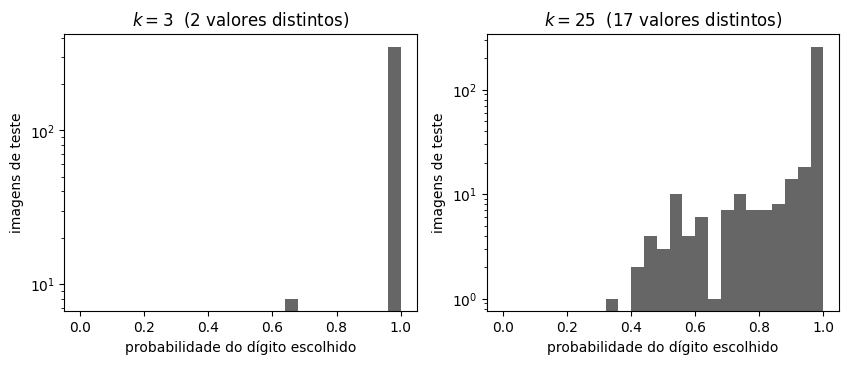

k =  3: 97.8% das imagens recebem probabilidade 1
k = 25: 61.1% das imagens recebem probabilidade 1


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

for ax, k_hist in zip(axes, (3, 25)):
    confianca = knn_probabilidades(D, y_treino, k_hist).max(axis=1)
    ax.hist(confianca, bins=np.linspace(0, 1, 26), color="0.4")
    ax.set_yscale("log")
    ax.set_title(f"$ k = {k_hist} $  "
                 f"({len(np.unique(confianca))} valores distintos)")
    ax.set_xlabel("probabilidade do dígito escolhido")
    ax.set_ylabel("imagens de teste")

plt.show()

for k_hist in (3, 25):
    confianca = knn_probabilidades(D, y_treino, k_hist).max(axis=1)
    print(f"k = {k_hist:2d}: {np.mean(confianca == 1):.1%} das imagens recebem "
          f"probabilidade 1")

Com $ k = 3 $, a votação é unânime em quase $ 98\% $ das imagens de teste, e o
modelo declara certeza absoluta em praticamente tudo. Isto é pouco útil: uma
medida de confiança que quase nunca varia não distingue os casos fáceis dos
difíceis.

Aqui aparece uma tensão que vale registrar. Em $ \S 2.5 $ vimos que a acurácia é
melhor para $ k $ pequeno. Agora vemos que as probabilidades só ficam
informativas para $ k $ grande. __O $ k $ que melhor classifica não é o $ k $ que
melhor quantifica a incerteza__, e qual deles escolher depende do que você
pretende fazer com a saída. No resto da seção usamos $ k = 25 $.

In [24]:
k_prob = 25

P_25 = knn_probabilidades(D, y_treino, k_prob)
previsoes_25 = P_25.argmax(axis=1)
confianca_25 = P_25.max(axis=1)
acertou = previsoes_25 == y_teste

print(f"Acurácia com k = {k_prob}: {acertou.mean():.4f}")

Acurácia com k = 25: 0.9611


### $ 3.3 $ A confiança sabe quando o modelo erra?

Se os números significam alguma coisa, os erros deveriam concentrar-se entre as
imagens de baixa confiança.

__Exercício:__ Compare a confiança média nas imagens que o modelo acertou e nas
que errou.

In [25]:
print(f"Confiança média quando acerta: {confianca_25[acertou].mean():.3f}")
print(f"Confiança média quando erra:   {confianca_25[~acertou].mean():.3f}")

Confiança média quando acerta: 0.933
Confiança média quando erra:   0.583


A separação é grande, e sugere um uso prático: se o modelo puder __se abster__
nos casos duvidosos, entregando-os a um humano, a acurácia sobre o que ele
resolve deve subir.

__Exercício:__ Ordene as imagens de teste da mais confiante para a menos
confiante e represente graficamente a acurácia acumulada contra a __cobertura__,
a fração de imagens sobre as quais o modelo se pronuncia. _Dica:_ `np.cumsum`
sobre o vetor booleano `acertou` reordenado, dividido por
`np.arange(1, n + 1)`.

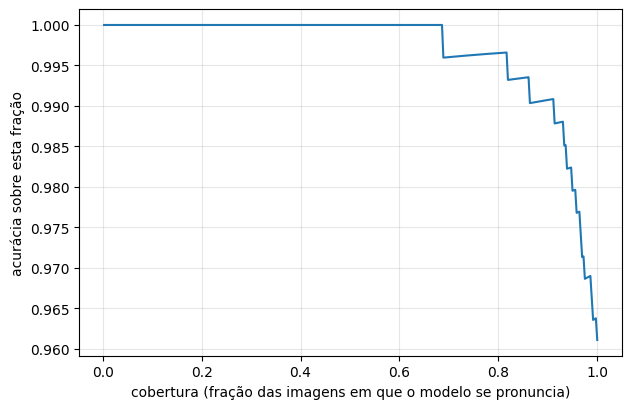

cobertura 1.00 -> acurácia 0.9611
cobertura 0.90 -> acurácia 0.9907
cobertura 0.80 -> acurácia 0.9965


In [26]:
ordem = np.argsort(confianca_25)[::-1]
n_teste = len(ordem)

cobertura = np.arange(1, n_teste + 1) / n_teste
acuracia_acumulada = np.cumsum(acertou[ordem]) / np.arange(1, n_teste + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(cobertura, acuracia_acumulada)
ax.set_xlabel("cobertura (fração das imagens em que o modelo se pronuncia)")
ax.set_ylabel("acurácia sobre esta fração")
ax.grid(alpha=0.3)

plt.show()

for alvo in (1.0, 0.9, 0.8):
    j = int(alvo * n_teste) - 1
    print(f"cobertura {cobertura[j]:.2f} -> acurácia {acuracia_acumulada[j]:.4f}")

Abrir mão das $ 20\% $ de imagens menos confiantes leva a acurácia de cerca de
$ 96\% $ para praticamente $ 100\% $. A confiança, portanto, ordena bem: ela sabe
onde estão os casos difíceis, mesmo que não saiba resolvê-los.

### $ 3.4 $ As probabilidades estão calibradas?

Ordenar bem é uma coisa; ser um número honesto é outra. Um modelo __calibrado__
é aquele em que, dentre as imagens às quais ele atribuiu probabilidade $ 0{,}7 $,
cerca de $ 70\% $ de fato pertencem ao dígito apontado.

__Exercício:__ Divida as imagens de teste em faixas de confiança. Para cada
faixa, calcule a confiança média e a acurácia observada, e represente uma contra
a outra. A diagonal é a calibração perfeita. Faça o tamanho do marcador crescer
com o número de imagens da faixa, para não dar peso visual a faixas quase
vazias.

[0.00, 0.50):  10 imagens, confiança 0.432, acurácia 0.600
[0.50, 0.70):  28 imagens, confiança 0.587, acurácia 0.750
[0.70, 0.80):  17 imagens, confiança 0.736, acurácia 0.941
[0.80, 0.90):  29 imagens, confiança 0.850, acurácia 0.966
[0.90, 0.95):  18 imagens, confiança 0.920, acurácia 1.000
[0.95, 1.00): 258 imagens, confiança 0.994, acurácia 0.996


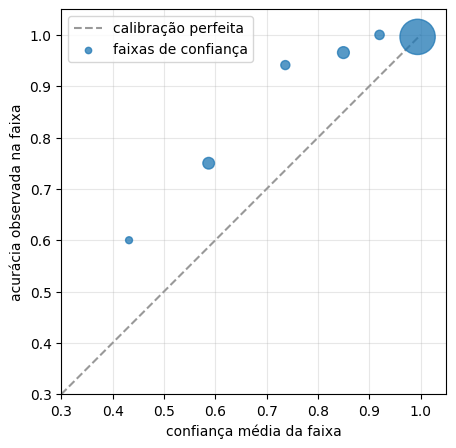

In [27]:
bordas = np.array([0.0, 0.5, 0.7, 0.8, 0.9, 0.95, 1.001])

confianca_media, acuracia_faixa, tamanho = [], [], []
for baixo, alto in zip(bordas[:-1], bordas[1:]):
    faixa = (confianca_25 >= baixo) & (confianca_25 < alto)
    if faixa.sum() > 0:
        confianca_media.append(confianca_25[faixa].mean())
        acuracia_faixa.append(acertou[faixa].mean())
        tamanho.append(faixa.sum())
        print(f"[{baixo:.2f}, {alto:.2f}): {faixa.sum():3d} imagens, "
              f"confiança {confianca_25[faixa].mean():.3f}, "
              f"acurácia {acertou[faixa].mean():.3f}")

fig, ax = plt.subplots(figsize=(5.5, 5))

ax.plot([0, 1], [0, 1], "--", color="0.6", label="calibração perfeita")
ax.scatter(confianca_media, acuracia_faixa, s=np.array(tamanho) * 2.5,
           alpha=0.75, zorder=3, label="faixas de confiança")
ax.set_xlabel("confiança média da faixa")
ax.set_ylabel("acurácia observada na faixa")
ax.set_xlim(0.3, 1.05); ax.set_ylim(0.3, 1.05)
ax.set_aspect("equal")
ax.legend(loc="upper left", markerscale=0.25)
ax.grid(alpha=0.3)

plt.show()

Os pontos ficam __acima__ da diagonal em toda a parte baixa da escala: quando o
modelo diz $ 0{,}59 $, ele acerta $ 75\% $ das vezes. Ele é subconfiante, isto é,
erra menos do que anuncia. Na ponta de cima, onde vive a grande maioria das
imagens, a calibração é quase exata.

Duas ressalvas honestas. As faixas baixas contêm poucas dezenas de imagens, de
modo que as suas acurácias trazem uma barra de erro considerável e não convém
ler demais nestes pontos. E toda esta análise usa o conjunto de teste, o mesmo
que já usamos para escolher $ k $ em $ \S 2.5 $; medir calibração com rigor pede
um terceiro conjunto, reservado desde o início.

### $ 3.5 $ Uma imagem de cada vez

As médias escondem os casos individuais, que são o que realmente interessa
quando se pergunta o que o modelo acha de uma imagem específica.

__Exercício:__ Selecione quatro imagens de teste ilustrativas e, para cada uma,
mostre a imagem e a distribuição $ \hat{p}(c \mid \boldsymbol{x}) $ sobre os dez
dígitos em um gráfico de barras. Escolha-as pelos extremos: um acerto
confiante, um acerto por pouco, um erro por pouco e um erro confiante. _Dica:_
combine a máscara `acertou` com `argmin` e `argmax` sobre `confianca_25`.

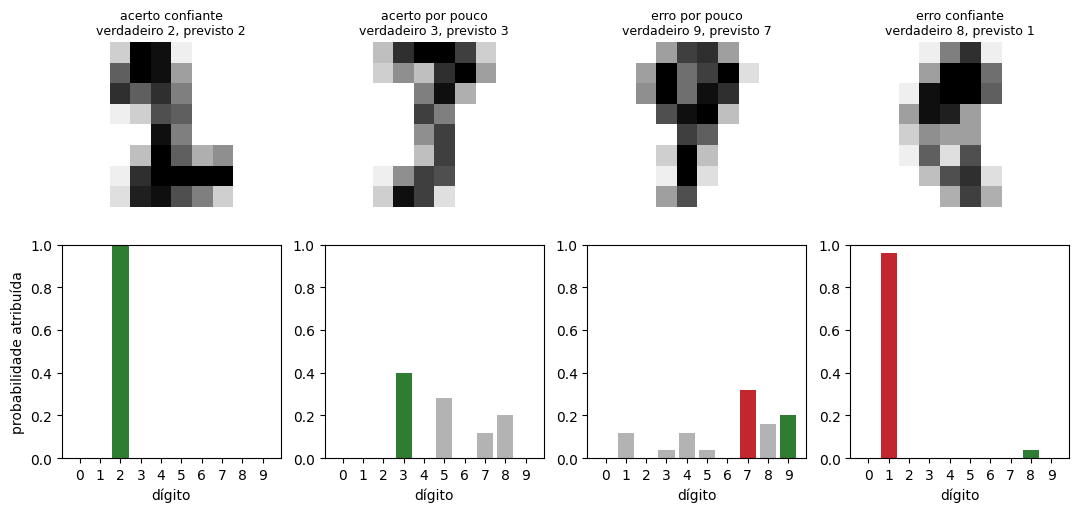

acerto confiante   teste   1: p(2) = 1.00, p(9) = 0.00, p(8) = 0.00
acerto por pouco   teste  21: p(3) = 0.40, p(5) = 0.28, p(8) = 0.20
erro por pouco     teste  93: p(7) = 0.32, p(9) = 0.20, p(8) = 0.16
erro confiante     teste  51: p(1) = 0.96, p(8) = 0.04, p(9) = 0.00


In [28]:
indices_certos = np.where(acertou)[0]
indices_errados = np.where(~acertou)[0]

casos = {
    "acerto confiante": indices_certos[np.argmax(confianca_25[indices_certos])],
    "acerto por pouco": indices_certos[np.argmin(confianca_25[indices_certos])],
    "erro por pouco":   indices_errados[np.argmin(confianca_25[indices_errados])],
    "erro confiante":   indices_errados[np.argmax(confianca_25[indices_errados])],
}

fig, axes = plt.subplots(2, 4, figsize=(13, 5.4),
                         gridspec_kw={"height_ratios": [1, 1.3]})

for coluna, (nome, i) in enumerate(casos.items()):
    axes[0, coluna].imshow(X_teste[i].reshape(8, 8), cmap="gray_r")
    axes[0, coluna].set_title(f"{nome}\nverdadeiro {y_teste[i]}, "
                              f"previsto {previsoes_25[i]}", fontsize=9)
    axes[0, coluna].axis("off")

    cores = ["0.7"] * 10
    cores[y_teste[i]] = "#2e7d32"
    if previsoes_25[i] != y_teste[i]:
        cores[previsoes_25[i]] = "#c1272d"
    axes[1, coluna].bar(range(10), P_25[i], color=cores)
    axes[1, coluna].set_xticks(range(10))
    axes[1, coluna].set_ylim(0, 1)
    axes[1, coluna].set_xlabel("dígito")

axes[1, 0].set_ylabel("probabilidade atribuída")

plt.show()

for nome, i in casos.items():
    tres = np.argsort(P_25[i])[::-1][:3]
    print(f"{nome:18s} teste {i:3d}: " +
          ", ".join(f"p({c}) = {P_25[i][c]:.2f}" for c in tres))

Verde marca o dígito verdadeiro e vermelho, quando aparece, o dígito previsto
por engano.

Os dois casos do meio são os interessantes. Neles a massa não se concentra em
dígito algum: espalha-se por três ou quatro candidatos, e o primeiro colocado
supera o segundo por apenas três vizinhos em vinte e cinco. Chamar o segundo
painel de acerto é generoso e o terceiro de erro é severo, porque os dois são a
mesma situação decidida em direções opostas por um punhado de votos. A
distribuição comunica algo que o rótulo sozinho jamais comunicaria: __o modelo
está em dúvida, e diz entre quais dígitos__. Um sistema real poderia oferecer as
alternativas em vez de fingir uma escolha.

O erro confiante é o caso desconfortável. O modelo atribui quase toda a massa ao
dígito errado, e nenhuma inspeção da distribuição avisaria que algo saiu mal. É o
lembrete de que a confiança alta ordena bem na média, mas não é garantia
nenhuma em um caso isolado.

### $ 3.6 $ ⚡ Ponderando pela distância

Na votação simples, o vizinho mais próximo e o vigésimo quinto pesam igual, o
que é estranho: se um deles está muito mais perto, deveria contar mais. Uma
correção comum é dar a cada vizinho peso $ 1/d $, com $ d $ a sua distância.

__Exercício:__ Escreva a versão ponderada e compare a acurácia com a da votação
simples para vários $ k $. _Dica:_ Para acumular pesos por classe sem laço em
Python, use `np.add.at` com um par de arrays de índices, um de linhas e um de
classes. A soma de cada linha precisa ser normalizada ao final.

In [29]:
def knn_probabilidades_ponderadas(D, y_treino, k, n_classes=10, eps=1e-12):
    """
    Estima a probabilidade de cada classe ponderando cada vizinho por 1 / distância.

    Parâmetros
    ----------
    D : ndarray de forma (n_teste, n_treino)
        Matriz das distâncias de cada amostra de teste a cada amostra de treino.
    y_treino : ndarray de forma (n_treino,)
        Rótulos das amostras de treino.
    k : int
        Número de vizinhos a consultar.
    n_classes : int, opcional
        Número de classes distintas.
    eps : float, opcional
        Termo que evita divisão por zero em imagens de teste idênticas a uma de treino.

    Retorna
    -------
    ndarray de forma (n_teste, n_classes)
        Cada linha soma 1.
    """
    indices = np.argsort(D, axis=1)[:, :k]
    pesos = 1.0 / (np.take_along_axis(D, indices, axis=1) + eps)

    P = np.zeros((len(D), n_classes))
    linhas = np.repeat(np.arange(len(D)), k)
    np.add.at(P, (linhas, y_treino[indices].ravel()), pesos.ravel())

    return P / P.sum(axis=1, keepdims=True)


print("   k    simples   ponderada")
for k_tentativa in (3, 9, 15, 25, 40, 60):
    simples = knn_probabilidades(D, y_treino, k_tentativa).argmax(axis=1)
    ponderada = knn_probabilidades_ponderadas(D, y_treino, k_tentativa).argmax(axis=1)
    print(f"{k_tentativa:4d}  {np.mean(simples == y_teste):9.4f}  "
          f"{np.mean(ponderada == y_teste):10.4f}")

   k    simples   ponderada
   3     0.9861      0.9861
   9     0.9806      0.9833
  15     0.9750      0.9833
  25     0.9611      0.9611
  40     0.9556      0.9639
  60     0.9278      0.9500


A ponderação ajuda, mas onde menos importa. Para $ k $ pequeno a diferença é nula
ou de uma ou duas imagens, porque os poucos vizinhos consultados já estão todos
perto e pesar por $ 1/d $ quase não reordena a votação. Para
$ k $ grande a ponderação reduz o estrago, ao amortecer a influência dos vizinhos
distantes que a votação simples deixava entrar com peso cheio. Nenhuma
configuração ponderada supera a votação simples com $ k $ pequeno.

📝 Este é o comportamento de `KNeighborsClassifier(weights="distance")`. Vale
notar o efeito colateral sobre as probabilidades: os pesos são contínuos, de modo
que a saída deixa de ser restrita a múltiplos de $ 1/k $ e ganha resolução mesmo
com $ k $ pequeno. Se o que você quer é uma medida de incerteza utilizável sem
sacrificar acurácia, esta é a alavanca a puxar.

⚡ __Exercício (a disposição dos pixels importa?):__ Seja $ P $ uma permutação
das $ 64 $ posições de pixel, aplicada de forma idêntica a todas as imagens. As
imagens se tornam ilegíveis ao olho humano.

(a) Mostre que permutar as coordenadas de dois vetores deixa inalterada a
    distância entre eles: $ \Vert P\boldsymbol{x} - P\boldsymbol{y}\Vert =
    \Vert \boldsymbol{x} - \boldsymbol{y}\Vert $. _Dica:_ A soma que define a
    norma é a mesma soma com os termos reordenados. Equivalentemente, uma matriz
    de permutação é ortogonal.

(b) Deduza que o método deste caderno dá _exatamente_ os mesmos resultados
    sobre os dados permutados e sobre os originais. Depois confirme
    numericamente com `permutacao = rng.permutation(64)` e
    `X_treino[:, permutacao]`. O mesmo vale para o $ k $-médias do caderno
    seguinte, pela mesma razão.

(c) Portanto, o método jamais usou o fato de que o pixel $ 9 $ fica logo
    abaixo do pixel $ 1 $. Ele trata uma imagem como um saco não ordenado de
    $ 64 $ números. Que tipo de informação está sendo jogada fora, e
    o que um método teria de fazer de diferente para explorá-la?

As matrizes de distâncias coincidem: True
As previsões coincidem:              True


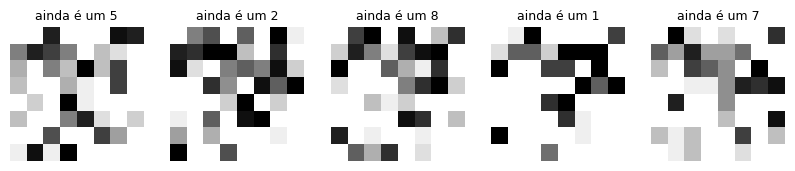

In [30]:
permutacao = rng.permutation(64)

D_permutada = np.sqrt(distancias_quadradas(X_teste[:, permutacao],
                                           X_treino[:, permutacao]))
print(f"As matrizes de distâncias coincidem: {np.allclose(D, D_permutada)}")
print(f"As previsões coincidem:              "
      f"{np.array_equal(knn_prever(D_permutada, y_treino, 3), previsoes)}")

fig, axes = plt.subplots(1, 5, figsize=(10, 2.4))

for c, ax in enumerate(axes.flat):
    ax.imshow(X_teste[c][permutacao].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"ainda é um {y_teste[c]}", fontsize=9)
    ax.axis("off")

plt.show()